# Computer Exercise 4.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.1 Polynomial Interpolation — *Chebyshev nodes and the minimax property*
> **풀이 일자**: Day 103
> **언어**: Python 3 (NumPy / pandas / Matplotlib / SciPy)

---

Problem 1 은 *형식을 바꿔도 정확도는 안 바뀐다* 를, Problem 2 는 *등간격 절점에서는 차수를
올릴수록 나빠진다* 를 보였다. 남은 자유도는 하나뿐이다 — **절점을 옮기는 것.**
오늘의 마지막 문제는 그 절점을 **최적화 문제의 해로** 얻고, 그 해가 Problem 2 의 세 가지
병 (절점다항식의 편중 · 위치별 발산 · $\Lambda_n\sim 2^n$) 을 **동시에** 고친다는 것을 잰다.

## 1. 문제 (원문)

> **Computer Exercise 4.1.3.** Repeat Computer Exercise 4.1.2 using the **Chebyshev nodes**
> $$x_i=\cos\frac{(2i+1)\pi}{2n+2}\quad(i=0,\dots,n)\qquad\text{(zeros of }T_{n+1})$$
> and also the **Chebyshev extreme points** $x_i=\cos(i\pi/n)$.
>
> (a) Verify numerically that for the zero nodes $\omega(x)=\prod_i(x-x_i)$ satisfies
> $\omega = 2^{-n}T_{n+1}$ and $\|\omega\|_\infty=2^{-n}$, and that this is the *smallest possible*
> value over all choices of $n+1$ nodes in $[-1,1]$ — the minimax property of the monic Chebyshev
> polynomial. Support this both by random sampling and by direct numerical minimization.
>
> (b) Tabulate $\max_{[-1,1]}|f-p_n|$ for $f=1/(1+25x^2)$, $|x|$, $e^{x}$ and compare with the
> equally spaced results. Show that the Runge function now converges **geometrically**, and compare
> the observed rate with the Bernstein-ellipse prediction $\rho=|z_0+\sqrt{z_0^2-1}|$ for the
> nearest singularity $z_0=i/5$.
>
> (c) Measure the Lebesgue constant of both Chebyshev families and compare with the known growth
> $\Lambda_n\sim\frac{2}{\pi}\log n$.
>
> (d) Push the degree to $n=300$ using the barycentric formula with the explicit Chebyshev weights,
> and contrast with what happens if the interpolant is instead represented in the monomial basis.

### 한국어 풀이용 정리

절점을 어떻게 놓아야 하는가? 오차식 $f^{(n+1)}(\xi)/(n+1)!\cdot\omega(x)$ 에서 우리가 **고를 수
있는 것은 $\omega$ 뿐**이다. 따라서 자연스러운 목표는

$$\min_{x_0,\dots,x_n\in[-1,1]}\ \bigl\|\textstyle\prod_i(x-x_i)\bigr\|_\infty$$

이고, 이 최소화 문제의 해는 **Chebyshev 다항식의 근**이며 최소값은 $2^{-n}$ 이다.
이 노트북은 (a) 그 최소성을 무작위 표본과 직접 최소화로 확인하고, (b) 그 결과가 Runge 함수의
**기하급수적 수렴**으로 나타남을 Bernstein 타원 예측과 대조하고, (c) Lebesgue 상수가
$2^{n}$ 에서 $\tfrac{2}{\pi}\log n$ 으로 내려앉음을 재고, (d) $n=300$ 까지 밀어 **무게중심 공식은
견디고 단항식 기저는 무너진다**는 것을 보인다.

## 2. 수학적 배경

### 2.1 Chebyshev 다항식

$T_k(\cos\theta)=\cos k\theta$, 즉 $T_k(x)=\cos(k\arccos x)$ 이고 $T_{k+1}=2xT_k-T_{k-1}$.
따라서 $T_k$ 의 최고차 계수는 $2^{k-1}$ ($k\ge1$) 이다. $T_{n+1}$ 의 근은

$$x_i=\cos\frac{(2i+1)\pi}{2n+2},\qquad i=0,\dots,n$$

이고, $|T_{n+1}|$ 은 $[-1,1]$ 에서 $n+2$ 개의 점 $\cos(j\pi/(n+1))$ 에서 **부호를 번갈아 가며**
최대값 $1$ 을 취한다 (**등진동, equioscillation**).

### 2.2 최소최대 성질

**정리 (Chebyshev).** $\tilde T_{n+1}=2^{-n}T_{n+1}$ 은 최고차 계수가 1 인 (monic) $n+1$ 차
다항식 중 $[-1,1]$ 위 sup-norm 이 최소인 유일한 것이며

$$\boxed{\;\min_{\substack{q\ \text{monic},\ \deg q=n+1}}\ \|q\|_{\infty,[-1,1]}=\|2^{-n}T_{n+1}\|_\infty=2^{-n}.\;}$$

*증명 스케치.* 더 작은 monic $q$ 가 있다면 $\tilde T_{n+1}-q$ 는 차수 $\le n$ 인데
$\tilde T_{n+1}$ 의 등진동 극점 $n+2$ 개에서 부호가 번갈아 바뀌므로 근이 $n+1$ 개 이상 —
모순. $\blacksquare$

$\omega(x)=\prod_{i}(x-x_i)$ 는 monic 이고 근이 $x_i$ 이므로, **절점을 $T_{n+1}$ 의 근으로
잡는 것**이 $\|\omega\|_\infty$ 를 최소화하는 유일한 방법이다. 등간격 절점의 값
($n=40$ 에서 $3.0\times10^{-7}$) 과 비교하면 $2^{-40}=9.1\times10^{-13}$ — **여섯 자리** 차이다.

### 2.3 Bernstein 타원과 수렴률

초점 $\pm1$, 이심 매개변수 $\rho>1$ 인 **Bernstein 타원**

$$E_\rho=\Bigl\{\tfrac12(u+u^{-1}) : |u|=\rho\Bigr\}$$

의 내부에서 $f$ 가 해석적이고 $|f|\le M$ 이면, Chebyshev 보간의 오차는

$$\boxed{\;\|f-p_n\|_\infty\ \le\ \frac{4M}{\rho-1}\,\rho^{-n}. \;}$$

가장 가까운 특이점 $z_0$ 를 지나는 타원의 매개변수는 $\rho=|z_0+\sqrt{z_0^2-1}|$ 이다.
Runge 함수는 $z_0=i/5$ 이므로

$$\rho=\Bigl|\tfrac{i}{5}+\sqrt{-\tfrac1{25}-1}\Bigr|=\tfrac15+\sqrt{\tfrac{26}{25}}=1.2198039\ldots,
\qquad \log\rho=0.1986927\ldots$$

즉 $\log\|f-p_n\|_\infty$ 의 $n$ 에 대한 기울기가 $-0.19869$ 여야 한다. 이 노트북은 이 값을
**측정**한다. (Problem 2 의 등간격에서는 같은 함수가 $x>0.7267$ 에서 발산했다 — 같은 함수,
같은 형식, **절점만 바뀌었다.**)

$|x|$ 는 어떤 타원 안에서도 해석적이지 않으므로 기하급수적 수렴이 불가능하고,
Chebyshev 절점에서 $O(1/n)$ 만 얻는다. $e^{x}$ 는 전해석이므로 $\rho$ 를 얼마든지 키울 수 있고
**초기하급수적**으로 수렴한다.

### 2.4 Lebesgue 상수

$$\Lambda_n^{\text{cheb}}=\frac{2}{\pi}\log n+O(1)\qquad\text{대}\qquad
\Lambda_n^{\text{equi}}\sim\frac{2^{n+1}}{e\,n\log n}.$$

더 정확히는, Chebyshev 절점의 점근식과 **모든 절점 배치에 대한 하한**이 다음과 같이 알려져 있다:

$$\Lambda_n^{\text{cheb}}=\frac{2}{\pi}\Bigl(\log n+\gamma+\log\tfrac{8}{\pi}\Bigr)+o(1)
=0.63662\log n+0.96253+o(1),$$
$$\Lambda_n\ \ge\ \Lambda_n^{\star}=\frac{2}{\pi}\Bigl(\log n+\gamma+\log\tfrac{4}{\pi}\Bigr)+o(1)
=0.63662\log n+0.52125+o(1)\qquad\text{(Erdős)}$$

즉 Chebyshev 절점은 최적 절점보다 **정확히 $\tfrac{2}{\pi}\log 2=0.44127$ 만큼** 나쁘고,
그 차이는 $n$ 에 무관한 상수다. 이 노트북은 그 상수를 **측정**한다.

### 2.5 무게중심 무게의 닫힌 형태

일반 절점에서는 무게 계산이 $O(n^2)$ 이지만 Chebyshev 절점에서는 공식이 있다:

$$\text{근 절점: } w_i=(-1)^i\sin\frac{(2i+1)\pi}{2n+2},\qquad
\text{극점 절점: } w_i=(-1)^i\delta_i,\ \ \delta_i=\tfrac12\ (i=0,n),\ 1\ \text{(그 외)}.$$

무게는 공통 상수배에 불변이므로 이대로 써도 된다. 계산이 $O(n)$ 이고 **크기가 모두 $O(1)$** 이라
오버플로가 없다 — 이것이 $n=300$ 까지 밀 수 있는 이유다.

## 3. 풀이 흐름

1. **절점족과 무게** — 등간격 / Chebyshev 근 / Chebyshev 극점. 닫힌 형태 무게가 일반 로그합
   무게와 상수배로 일치하는지 먼저 검증.
2. **(a) 최소최대** — $\|\omega\|_\infty$ 를 세 절점족에서 재고 $2^{-n}$ 과 대조. $\omega$ 가
   $2^{-n}T_{n+1}$ 과 같은지 조밀격자에서 확인하고 등진동 극점의 개수·부호 교대를 센다.
   하한임을 세 가지로 지지: **무작위 절점 $2\times10^5$ 세트**, **Chebyshev 절점 주변의 국소
   섭동**, 그리고 **$L^p$ 완화를 이용한 직접 최소화** (sup-norm 은 미분 불가하므로
   $p=20\to800$ 으로 $\|\cdot\|_p$ 를 최소화하며 연속적으로 $p$ 를 올린다).
3. **(b) 수렴** — 세 함수 × $n=2\ldots60$ 에서 최대오차. Runge 의 $\log$-기울기를 적합해
   $-\log\rho=-0.1986927$ 과 비교. $|x|$ 는 $\log$–$\log$ 기울기로 $-1$ 확인.
   같은 표에 Problem 2 의 등간격 결과를 나란히 둔다.
4. **(c) Lebesgue** — 두 Chebyshev 족의 $\Lambda_n$ 을 $n\le 300$ 에서 재고 $A\log n+B$ 로
   적합해 $A$ 를 $2/\pi=0.63662$ 와 비교. Erdős 하한과의 간격이 $\tfrac2\pi\log 2$ 로
   수렴하는지도 확인.
5. **(d) 고차 안정성** — $n$ 을 $300$ 까지 밀어 무게중심 형식의 오차를 재고, 같은 $n$ 에서
   단항식(Vandermonde) 형식이 어디서 무너지는지 본다.
6. **시각화** — 6 패널.

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  절점족과 무게 — 닫힌 형태 무게의 검증
# ══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import math

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
pd.set_option("display.width", 220)
eps = np.finfo(float).eps
rng = np.random.default_rng(103_003)

def nodes_equi(n):   return np.linspace(-1.0, 1.0, n+1)
def nodes_cheb1(n):  # T_{n+1} 의 근
    k = np.arange(n+1); return np.cos((2*k+1)*np.pi/(2*n+2))
def nodes_cheb2(n):  # T_n 의 극점 (Chebyshev–Lobatto)
    k = np.arange(n+1); return np.cos(k*np.pi/n)

def w_cheb1(n):
    k = np.arange(n+1); return (-1.0)**k * np.sin((2*k+1)*np.pi/(2*n+2))
def w_cheb2(n):
    k = np.arange(n+1); w = (-1.0)**k * np.ones(n+1); w[0] *= 0.5; w[-1] *= 0.5; return w

def w_logsum(xn):
    xn = np.asarray(xn, float); D = xn[:, None] - xn[None, :]
    np.fill_diagonal(D, 1.0)
    logs = np.log(np.abs(D)).sum(axis=1)
    sign = np.where(((D < 0).sum(axis=1) % 2) == 1, -1.0, 1.0)
    l = -logs; l -= l.max(); return sign*np.exp(l)

def bary_eval(xn, yn, w, xe):
    xe = np.atleast_1d(np.asarray(xe, float)).copy()
    num = np.zeros_like(xe); den = np.zeros_like(xe)
    ex = np.full(xe.shape, -1, dtype=int)
    for i in range(xn.size):
        dx = xe - xn[i]
        hit = (dx == 0.0); ex[hit] = i; dx[hit] = 1.0
        t = w[i]/dx; num += t*yn[i]; den += t
    out = num/den; m = ex >= 0; out[m] = np.asarray(yn)[ex[m]]
    return out

def lebesgue_fn(xn, w, xe):
    xe = np.atleast_1d(np.asarray(xe, float)).copy()
    num = np.zeros_like(xe); den = np.zeros_like(xe); ex = np.zeros(xe.shape, bool)
    for i in range(xn.size):
        dx = xe - xn[i]
        hit = (dx == 0.0); ex |= hit; dx[hit] = 1.0
        t = w[i]/dx; num += np.abs(t); den += t
    lam = num/np.abs(den); lam[ex] = 1.0
    return lam

def log_abs_omega(xn, xe):
    with np.errstate(divide="ignore"):
        return np.log(np.abs(np.atleast_1d(xe)[:, None] - np.asarray(xn)[None, :])).sum(axis=1)

f_runge = lambda x: 1.0/(1.0 + 25.0*x**2)
f_abs   = lambda x: np.abs(x)
f_exp   = lambda x: np.exp(x)
FUNCS = [("Runge", f_runge), ("|x|", f_abs), ("exp(x)", f_exp)]

print("닫힌 형태 Chebyshev 무게가 일반 로그합 무게와 상수배로 일치하는가")
for n in [8, 20, 50]:
    for nm, nd, wf in (("roots", nodes_cheb1, w_cheb1), ("extrema", nodes_cheb2, w_cheb2)):
        xn = nd(n); r = wf(n)/w_logsum(xn)
        print(f"  n={n:3d} {nm:8s} :  비의 최대/최소 = {r.max()/r.min():.12f}"
              f"   (부호 일치 {np.all(np.sign(wf(n))==np.sign(w_logsum(xn)))})")
xdd = np.linspace(-1, 1, 2001)
n = 30; xn = nodes_cheb1(n)
p_cl = bary_eval(xn, f_runge(xn), w_cheb1(n), xdd)
p_lg = bary_eval(xn, f_runge(xn), w_logsum(xn), xdd)
print(f"\n  두 무게로 얻은 보간값의 최대 차 (n=30) = {np.max(np.abs(p_cl-p_lg)):.3e}")
print(f"  닫힌 형태 무게의 크기 범위 : [{np.abs(w_cheb1(50)).min():.3e},"
      f" {np.abs(w_cheb1(50)).max():.3e}]  — n 과 무관하게 O(1), 오버플로 없음")


닫힌 형태 Chebyshev 무게가 일반 로그합 무게와 상수배로 일치하는가
  n=  8 roots    :  비의 최대/최소 = 1.000000000000   (부호 일치 True)
  n=  8 extrema  :  비의 최대/최소 = 1.000000000000   (부호 일치 True)
  n= 20 roots    :  비의 최대/최소 = 1.000000000000   (부호 일치 True)
  n= 20 extrema  :  비의 최대/최소 = 1.000000000000   (부호 일치 True)
  n= 50 roots    :  비의 최대/최소 = 1.000000000000   (부호 일치 True)
  n= 50 extrema  :  비의 최대/최소 = 1.000000000000   (부호 일치 True)

  두 무게로 얻은 보간값의 최대 차 (n=30) = 9.992e-16
  닫힌 형태 무게의 크기 범위 : [3.080e-02, 1.000e+00]  — n 과 무관하게 O(1), 오버플로 없음


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  (a) 최소최대 성질 :  ||omega||_inf = 2^{-n} 이 정말 하한인가
# ══════════════════════════════════════════════════════════════════════════
xg = np.linspace(-1, 1, 200001)
rows = []
for n in [4, 8, 12, 16, 20, 30, 40]:
    r_ = math.exp(log_abs_omega(nodes_cheb1(n), xg).max())
    e_ = math.exp(log_abs_omega(nodes_cheb2(n), xg).max())
    q_ = math.exp(log_abs_omega(nodes_equi(n),  xg).max())
    rows.append(dict(n=n, cheb_roots=r_, theory_2pow=2.0**(-n), rel_err=abs(r_-2.0**(-n))*2.0**n,
                     cheb_extrema=e_, equispaced=q_, equi_over_cheb=q_/r_))
O = pd.DataFrame(rows)
print("||omega||_inf  (omega = prod (x - x_i),  x in [-1,1])")
print(O.to_string(index=False))
print("\n  · cheb_roots 가 2^{-n} 과 일치 (rel_err = |측정 - 2^-n| / 2^-n)")
print(f"  · 등간격 대비 이득 : n=20 에서 {O[O.n==20].equi_over_cheb.iloc[0]:.3e} 배,"
      f" n=40 에서 {O[O.n==40].equi_over_cheb.iloc[0]:.3e} 배")
print(f"  · 극점 절점은 2^{{-n}} 의 {O[O.n==20].cheb_extrema.iloc[0]/O[O.n==20].cheb_roots.iloc[0]:.4f} 배"
      f" (= 2 배; 극점 절점은 omega 최소화의 해가 아니다)")

# --- omega == 2^{-n} T_{n+1} 인가, 그리고 등진동 ---
n = 12; xn = nodes_cheb1(n)
om = np.exp(log_abs_omega(xn, xg)) * np.sign(np.prod(np.sign(xg[:, None]-xn[None, :]), axis=1))
Tn1 = np.cos((n+1)*np.arccos(np.clip(xg, -1, 1)))
print(f"\nomega = 2^(-n) T_(n+1) 검증 (n={n}) : 최대 절대차"
      f" = {np.max(np.abs(om - 2.0**(-n)*Tn1)):.3e}   (규모 2^-n = {2.0**(-n):.3e})")
extpts = np.cos(np.arange(n+2)*np.pi/(n+1))
vals = np.exp(log_abs_omega(xn, extpts))*np.sign(np.prod(np.sign(extpts[:,None]-xn[None,:]),axis=1))
sgn = np.sign(vals)
print(f"  등진동 극점 {len(extpts)} 개에서 |omega| = "
      f"{np.abs(vals).min():.6e} ~ {np.abs(vals).max():.6e}  (모두 2^-n)")
print(f"  부호 교대 여부 : {bool(np.all(sgn[:-1]*sgn[1:] < 0))}  "
      f"(n+2 = {n+2} 개 점에서 교대 → 최소최대 정리의 조건)")

# --- 무작위 표본으로 하한 지지 ---
print("\n무작위 절점 표본 (각 n 마다 100,000 세트, 균등분포) — 2^{-n} 보다 작은 것이 나오는가")
xgs_rand = xg[::250]          # 801 점 부격자
for n in [4, 6, 8]:
    best = np.inf; N = 100_000
    for _ in range(20):
        Xs = rng.uniform(-1, 1, size=(N//20, n+1))
        v = np.exp(np.log(np.abs(xgs_rand[None, :, None] - Xs[:, None, :])).sum(axis=2)).max(axis=1)
        best = min(best, v.min())
    print(f"  n={n} : 최소 ||omega|| = {best:.6e},  2^(-n) = {2.0**(-n):.6e},"
          f"  비 = {best/2.0**(-n):.4f}   {'(하한 유지)' if best >= 2.0**(-n)*0.999 else '(위반!)'}")
print("  ※ sup 은 801 점 부격자에서 잰 값이라 약간 과소평가될 수 있다 — 즉 이 시험은 보수적이다.")

# --- Chebyshev 절점 주변의 국소 섭동 : 정말 국소최소인가 ---
print("\n국소 섭동 (Chebyshev 근에 균등잡음 delta 를 더해 20,000 회씩) — ||omega|| 가 늘기만 하는가")
xgs = xg[::100]               # 2001 점 부격자
NP_ = 20_000
for n in [6, 10]:
    base = nodes_cheb1(n)
    for delta in [1e-3, 1e-2, 1e-1]:
        mn, cnt = np.inf, 0
        for _ in range(10):
            Z = np.clip(base[None, :] + rng.uniform(-delta, delta, size=(NP_//10, n+1)), -1, 1)
            with np.errstate(divide="ignore"):     # 섭동 절점이 격자점과 겹치면 log(0)
                v = np.exp(np.log(np.abs(xgs[None, :, None] - Z[:, None, :])).sum(axis=2)).max(axis=1)
            mn = min(mn, v.min()); cnt += int((v < 2.0**(-n)*(1-1e-12)).sum())
        print(f"  n={n:2d} delta={delta:.0e} : 최소 비 = {mn/2.0**(-n):.8f},"
              f"  2^-n 미만 개수 = {cnt} / {NP_}")

# --- 직접 최소화 : sup-norm 을 L^p 완화로 (p 를 20 -> 800 으로 올리며) ---
def obj_Lp(z, p, grid):
    z = np.clip(np.asarray(z, float), -1, 1)
    L = np.log(np.abs(grid[:, None] - z[None, :]) + 1e-300).sum(axis=1)
    m = L.max()
    return m + np.log(np.mean(np.exp(p*(L - m))))/p

def sup_omega(z):
    xf = np.linspace(-1, 1, 200001)
    return math.exp(np.log(np.abs(xf[:, None] - np.asarray(z)[None, :])).sum(axis=1).max())

print("\n직접 최소화 (L^p 완화 + Nelder–Mead, 무작위 시작 6 회) — 최적 절점은 Chebyshev 근인가")
go = np.linspace(-1, 1, 2001)
for n in [4, 6]:
    best_v, best_z = np.inf, None
    for _ in range(6):
        z = np.sort(rng.uniform(-1, 1, n+1))
        for p in [20, 60, 200, 800]:
            z = minimize(lambda t: obj_Lp(t, p, go), z, method="Nelder-Mead",
                         options=dict(maxiter=20000, maxfev=20000,
                                      xatol=1e-12, fatol=1e-14)).x
        v = sup_omega(z)
        if v < best_v: best_v, best_z = v, np.sort(np.clip(z, -1, 1))
    tgt = np.sort(nodes_cheb1(n))
    print(f"  n={n} : 최소값 {best_v:.8e}   2^(-n) = {2.0**(-n):.8e}"
          f"   비 = {best_v/2.0**(-n):.6f}")
    print(f"        최적 절점  {np.round(best_z, 6)}")
    print(f"        Chebyshev  {np.round(tgt, 6)}   최대 절점차 = {np.max(np.abs(best_z-tgt)):.2e}")
print("\n  ※ 비가 1 을 아주 조금 넘는 것은 유한 격자(2001 점)와 유한 p 때문이며,")
print("     아래로는 어떤 방법으로도 2^-n 을 뚫지 못한다 — 정리와 일치한다.")


||omega||_inf  (omega = prod (x - x_i),  x in [-1,1])
 n  cheb_roots  theory_2pow    rel_err  cheb_extrema  equispaced  equi_over_cheb
 4  6.2500e-02   6.2500e-02 8.8818e-16    1.1606e-01  1.1348e-01      1.8157e+00
 8  3.9063e-03   3.9062e-03 4.6629e-15    7.6647e-03  1.8803e-02      4.8136e+00
12  2.4414e-04   2.4414e-04 5.9952e-15    4.8413e-04  4.0080e-03      1.6417e+01
16  1.5259e-05   1.5259e-05 9.3259e-15    3.0371e-05  9.4270e-04      6.1781e+01
20  9.5367e-07   9.5367e-07 7.1054e-15    1.9015e-06  2.3367e-04      2.4502e+02
30  9.3132e-10   9.3132e-10 4.7073e-14    1.8601e-09  8.0644e-06      8.6591e+03
40  9.0949e-13   9.0949e-13 4.6185e-14    1.8176e-12  3.0484e-07      3.3518e+05

  · cheb_roots 가 2^{-n} 과 일치 (rel_err = |측정 - 2^-n| / 2^-n)
  · 등간격 대비 이득 : n=20 에서 2.450e+02 배, n=40 에서 3.352e+05 배
  · 극점 절점은 2^{-n} 의 1.9939 배 (= 2 배; 극점 절점은 omega 최소화의 해가 아니다)

omega = 2^(-n) T_(n+1) 검증 (n=12) : 최대 절대차 = 2.561e-18   (규모 2^-n = 2.441e-04)
  등진동 극점 14 개에서 |omega| = 2.441406e-04

  n=4 : 최소 ||omega|| = 7.984537e-02,  2^(-n) = 6.250000e-02,  비 = 1.2775   (하한 유지)


  n=6 : 최소 ||omega|| = 2.380791e-02,  2^(-n) = 1.562500e-02,  비 = 1.5237   (하한 유지)


  n=8 : 최소 ||omega|| = 8.210149e-03,  2^(-n) = 3.906250e-03,  비 = 2.1018   (하한 유지)
  ※ sup 은 801 점 부격자에서 잰 값이라 약간 과소평가될 수 있다 — 즉 이 시험은 보수적이다.

국소 섭동 (Chebyshev 근에 균등잡음 delta 를 더해 20,000 회씩) — ||omega|| 가 늘기만 하는가


  n= 6 delta=1e-03 : 최소 비 = 1.00266452,  2^-n 미만 개수 = 0 / 20000


...

  n=10 delta=1e-03 : 최소 비 = 1.00623777,  2^-n 미만 개수 = 0 / 20000


  n=10 delta=1e-02 : 최소 비 = 1.04177159,  2^-n 미만 개수 = 0 / 20000


  n=10 delta=1e-01 : 최소 비 = 1.44408079,  2^-n 미만 개수 = 0 / 20000

직접 최소화 (L^p 완화 + Nelder–Mead, 무작위 시작 6 회) — 최적 절점은 Chebyshev 근인가


  n=4 : 최소값 6.26183809e-02   2^(-n) = 6.25000000e-02   비 = 1.001894
        최적 절점  [-0.950972 -0.587663  0.        0.587663  0.950972]
        Chebyshev  [-0.951057 -0.587785  0.        0.587785  0.951057]   최대 절점차 = 1.23e-04


  n=6 : 최소값 1.56497528e-02   2^(-n) = 1.56250000e-02   비 = 1.001584
        최적 절점  [-0.974898 -0.781748 -0.43382   0.        0.43382   0.781748  0.974898]
        Chebyshev  [-0.974928 -0.781831 -0.433884  0.        0.433884  0.781831  0.974928]   최대 절점차 = 8.35e-05

  ※ 비가 1 을 아주 조금 넘는 것은 유한 격자(2001 점)와 유한 p 때문이며,
     아래로는 어떤 방법으로도 2^-n 을 뚫지 못한다 — 정리와 일치한다.


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  (b) 수렴 —  Bernstein 타원이 예측하는 기하급수적 수렴률
# ══════════════════════════════════════════════════════════════════════════
xd = np.linspace(-1, 1, 20001)
ns = list(range(2, 61, 2))
res = {}
for fam, nd, wf in (("equi", nodes_equi, None), ("cheb", nodes_cheb1, w_cheb1)):
    for name, f in FUNCS:
        errs = []
        for n in ns:
            xn = nd(n); w = wf(n) if wf is not None else w_logsum(xn)
            errs.append(np.max(np.abs(bary_eval(xn, f(xn), w, xd) - f(xd))))
        res[f"{name}/{fam}"] = errs
R = pd.DataFrame(res, index=pd.Index(ns, name="n"))
cols = ["Runge/equi","Runge/cheb","|x|/equi","|x|/cheb","exp(x)/equi","exp(x)/cheb"]
print("최대오차 max_{[-1,1]}|f - p_n| — 등간격 대 Chebyshev 근")
print(R[cols].to_string())

z0 = 0.2j
rho = abs(z0 + np.sqrt(z0**2 - 1))
rho_alt = abs(z0 - np.sqrt(z0**2 - 1))
rho = max(rho, rho_alt)
print(f"\nBernstein 타원 : z0 = i/5 → rho = {rho:.10f}"
      f"  (= 1/5 + sqrt(26)/5 = {0.2+math.sqrt(26)/5:.10f})")
print(f"  예측 기울기 d log(err)/dn = -log(rho) = {-math.log(rho):.7f}")

rc = R["Runge/cheb"].values
sel = (np.array(ns) >= 10) & (np.array(ns) <= 46)      # 반올림 바닥 위쪽 구간
sl, ic = np.polyfit(np.array(ns)[sel], np.log(rc[sel]), 1)
print(f"  측정 기울기 (n = 10..46)           = {sl:.7f}")
print(f"  → 측정 rho = exp(-slope) = {math.exp(-sl):.7f}   이론 {rho:.7f}"
      f"   상대차 {abs(math.exp(-sl)-rho)/rho*100:.3f} %")
r2 = 1 - np.sum((np.log(rc[sel]) - (sl*np.array(ns)[sel]+ic))**2) / \
         np.sum((np.log(rc[sel]) - np.log(rc[sel]).mean())**2)
print(f"  적합 R^2 = {r2:.6f}")
M = 1.0
print(f"  이론 상계 4M/(rho-1) * rho^-n :  n=20 → {4*M/(rho-1)*rho**-20:.3e}"
      f"  (측정 {rc[ns.index(20)]:.3e}),   n=40 → {4*M/(rho-1)*rho**-40:.3e}"
      f"  (측정 {rc[ns.index(40)]:.3e})")

ac = R["|x|/cheb"].values
sl2 = np.polyfit(np.log(np.array(ns)[4:]), np.log(ac[4:]), 1)[0]
print(f"\n|x| (Chebyshev) : log-log 기울기 = {sl2:.4f}   (이론 -1, 즉 O(1/n))")
print(f"  n=60 에서 오차 {ac[-1]:.4e},   n * err = {60*ac[-1]:.5f}  (n=40 에서 {40*ac[ns.index(40)]:.5f})")
print(f"  참고 : 최선근사는 E_n(|x|) ~ 0.2801/n (Bernstein 상수). 보간은 그보다 나쁘고,")
print(f"         Lebesgue 부등식 상계 (1+Lambda_n) E_n 은 n=60 에서"
      f" {(1+3.58)*0.2801/60:.4e} — 측정 {ac[-1]:.4e} 가 그 안에 든다.")
ec = R["exp(x)/cheb"].values
print(f"\nexp(x) (Chebyshev) : n=14 에서 {ec[ns.index(14)]:.3e},"
      f" n=20 이후 바닥 {ec[ns.index(20):].max():.3e} — 초기하급수 수렴 후 반올림 바닥")

print("\n같은 n 에서 등간격 대비 Chebyshev 의 이득 (Runge)")
gain = pd.DataFrame({"n": ns, "equi": R["Runge/equi"].values, "cheb": rc,
                     "gain": R["Runge/equi"].values/rc})
print(gain[gain.n.isin([10,20,30,40,50,60])].to_string(index=False))


최대오차 max_{[-1,1]}|f - p_n| — 등간격 대 Chebyshev 근
    Runge/equi  Runge/cheb   |x|/equi   |x|/cheb  exp(x)/equi  exp(x)/cheb
n                                                                         
2   6.4623e-01  6.0060e-01 2.5000e-01 2.1651e-01   7.8526e-02   5.6468e-02
4   4.3836e-01  4.0202e-01 1.4720e-01 1.2318e-01   1.1244e-03   6.3970e-04
6   6.1695e-01  2.6423e-01 1.8194e-01 8.6657e-02   9.9800e-06   3.6201e-06
8   1.0452e+00  1.7084e-01 3.1575e-01 6.6975e-02   5.8011e-08   1.2190e-08
10  1.9157e+00  1.0915e-01 6.6355e-01 5.4622e-02   2.3510e-10   2.7140e-11
12  3.6634e+00  6.9216e-02 1.5746e+00 4.6133e-02   7.4030e-13   4.3965e-14
14  7.1949e+00  4.6602e-02 4.0623e+00 3.9936e-02   1.2923e-13   2.2204e-15
16  1.4394e+01  3.2614e-02 1.1137e+01 3.5210e-02   4.0812e-13   2.2204e-15
18  2.9191e+01  2.2492e-02 3.1976e+01 3.1486e-02   3.8947e-13   2.6645e-15
20  5.9822e+01  1.5334e-02 9.5189e+01 2.8476e-02   1.4888e-11   2.6645e-15
22  1.2362e+02  1.0359e-02 2.9175e+02 2.5992e-02   6.

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  (c) Lebesgue 상수 :  2^n  ->  (2/pi) log n
# ══════════════════════════════════════════════════════════════════════════
xL = np.linspace(-1, 1, 40001)
ns_L = [4, 8, 16, 32, 64, 128, 200, 300]
rows = []
for n in ns_L:
    l1 = lebesgue_fn(nodes_cheb1(n), w_cheb1(n), xL).max()
    l2 = lebesgue_fn(nodes_cheb2(n), w_cheb2(n), xL).max()
    gam = 0.5772156649015329
    cheb_asym = 2/math.pi*(math.log(n) + gam + math.log(8/math.pi))
    opt_lower = 2/math.pi*(math.log(n) + gam + math.log(4/math.pi))
    row = dict(n=n, cheb_roots=l1, cheb_extrema=l2,
               cheb_asymptotic=cheb_asym, optimal_lower=opt_lower,
               gap=l2-opt_lower)
    if n <= 32:
        row["equispaced"] = lebesgue_fn(nodes_equi(n), w_logsum(nodes_equi(n)), xL).max()
    else:
        row["equispaced"] = np.nan
    rows.append(row)
LB = pd.DataFrame(rows)
print("Lebesgue 상수  (cheb_asymptotic = (2/pi)(log n + gamma + log(8/pi)),")
print("                optimal_lower  = (2/pi)(log n + gamma + log(4/pi)) = Erdos 하한)")
print(LB[["n","cheb_roots","cheb_extrema","cheb_asymptotic","optimal_lower","gap","equispaced"]]
      .to_string(index=False))

hi = LB[LB.n >= 16]
A1, B1 = np.polyfit(np.log(hi.n), hi.cheb_roots, 1)
A2, B2 = np.polyfit(np.log(hi.n), hi.cheb_extrema, 1)
print(f"\n적합  Lambda_n = A log n + B   (n >= 16 만 사용; 작은 n 은 o(1) 항이 크다)")
print(f"  roots   : A = {A1:.6f},  B = {B1:+.6f}")
print(f"  extrema : A = {A2:.6f},  B = {B2:+.6f}")
print(f"  이론    : A = 2/pi = {2/math.pi:.6f},"
      f"  B = (2/pi)(gamma+log(8/pi)) = {2/math.pi*(0.5772156649+math.log(8/math.pi)):.6f}")
print(f"  상대차  : roots A {abs(A1-2/math.pi)/(2/math.pi)*100:.2f} %,"
      f"  extrema A {abs(A2-2/math.pi)/(2/math.pi)*100:.2f} %")

print(f"\n  Chebyshev 극점 절점과 Erdos 하한의 간격 — 이론 (2/pi) log 2 = {2/math.pi*math.log(2):.6f}")
for _, r in LB.iterrows():
    print(f"    n={int(r.n):4d} : Lambda(extrema) {r.cheb_extrema:7.4f}"
          f"   하한 {r.optimal_lower:7.4f}   간격 {r.gap:+.6f}")
print(f"  → n=300 에서 간격 {LB[LB.n==300].gap.iloc[0]:.6f}"
      f"  vs 이론 {2/math.pi*math.log(2):.6f}"
      f"   (차 {abs(LB[LB.n==300].gap.iloc[0]-2/math.pi*math.log(2)):.2e})")
print("     즉 Chebyshev 는 최적 절점보다 정확히 상수 (2/pi)log2 만큼 나쁘고, 그 차는 n 과 무관하다.")
print(f"\n  n=300 에서 : Chebyshev {LB[LB.n==300].cheb_roots.iloc[0]:.3f} 대"
      f" 등간격 (외삽) 2^301/(e*300*log300) = {2.0**301/(math.e*300*math.log(300)):.3e}")
print(f"  → eps*Lambda_n : Chebyshev n=300 에서"
      f" {eps*LB[LB.n==300].cheb_roots.iloc[0]:.3e}  (반올림이 사실상 증폭되지 않는다)")


Lebesgue 상수  (cheb_asymptotic = (2/pi)(log n + gamma + log(8/pi)),
                optimal_lower  = (2/pi)(log n + gamma + log(4/pi)) = Erdos 하한)
  n  cheb_roots  cheb_extrema  cheb_asymptotic  optimal_lower        gap  equispaced
  4  1.9889e+00    1.7988e+00       1.8451e+00     1.4038e+00 3.9497e-01  2.2078e+00
  8  2.3619e+00    2.2747e+00       2.2863e+00     1.8451e+00 4.2967e-01  1.0946e+01
 16  2.7664e+00    2.7247e+00       2.7276e+00     2.2863e+00 4.3837e-01  9.3453e+02
 32  3.1885e+00    3.1682e+00       3.1689e+00     2.7276e+00 4.4055e-01  2.4309e+07
 64  3.6200e+00    3.6100e+00       3.6102e+00     3.1689e+00 4.4109e-01         NaN
128  4.0564e+00    4.0514e+00       4.0514e+00     3.6102e+00 4.4121e-01         NaN
200  4.3387e+00    4.3355e+00       4.3355e+00     3.8943e+00 4.4125e-01         NaN
300  4.5958e+00    4.5936e+00       4.5937e+00     4.1524e+00 4.4123e-01         NaN

적합  Lambda_n = A log n + B   (n >= 16 만 사용; 작은 n 은 o(1) 항이 크다)
  roots   : A = 0.624853,

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  (d) 고차로 밀기 —  무게중심은 견디고 단항식은 무너진다
# ══════════════════════════════════════════════════════════════════════════
xh = np.linspace(-1, 1, 20001)
def monomial_interp_err(xn, f, xe):
    V = np.vander(xn, increasing=True)
    try:
        a = np.linalg.solve(V, f(xn))
    except np.linalg.LinAlgError:
        return np.nan, np.inf
    out = np.full(xe.shape, a[-1])
    for k in range(a.size-2, -1, -1):
        out = out*xe + a[k]
    return np.max(np.abs(out - f(xe))), np.linalg.cond(V)

rows = []
np.seterr(all="ignore")
for n in [20, 40, 60, 80, 100, 150, 200, 300]:
    xn = nodes_cheb1(n); w = w_cheb1(n)
    e_bary = np.max(np.abs(bary_eval(xn, f_runge(xn), w, xh) - f_runge(xh)))
    e_mono, kap = (np.nan, np.nan)
    if n <= 100:
        e_mono, kap = monomial_interp_err(xn, f_runge, xh)
    lam = lebesgue_fn(xn, w, xh).max()
    rows.append(dict(n=n, bary_err=e_bary, monomial_err=e_mono, condV=kap,
                     Lambda=lam, eps_Lambda=eps*lam,
                     bernstein=4.0/(rho-1)*rho**-n))
np.seterr(all="warn")
H = pd.DataFrame(rows)
print("Runge 함수, Chebyshev 근 절점 — 고차에서의 두 형식")
print(H.to_string(index=False))
print(f"\n  · 무게중심 : n=60 에서 이미 {H[H.n==60].bary_err.iloc[0]:.2e},"
      f" n=300 에서 {H[H.n==300].bary_err.iloc[0]:.2e} — 기계정밀도 근처에서 **평평**")
print(f"  · 단항식   : n=20 에서 {H[H.n==20].monomial_err.iloc[0]:.2e} (무게중심과 동급) 이지만")
print(f"               n=100 에서 {H[H.n==100].monomial_err.iloc[0]:.2e}"
      f" — kappa_2(V) = {H[H.n==100].condV.iloc[0]:.2e}")
H["mono_over_bary"] = H.monomial_err / H.bary_err
bad = H[(H.n <= 100) & (H.mono_over_bary > 10)]
print(f"  · 단항식/무게중심 오차비 : "
      + ", ".join(f"n={int(r.n)}:{r.mono_over_bary:.3g}"
                  for _, r in H[H.n <= 100].iterrows()))
print(f"  · 단항식이 무게중심보다 10 배 이상 나빠지는 첫 n : "
      f"{int(bad.n.iloc[0]) if len(bad) else '없음 (n<=100)'}")
print(f"  · 반올림 바닥 eps*Lambda_n 은 n=300 에서 {H[H.n==300].eps_Lambda.iloc[0]:.2e}"
      f" — 측정 오차 {H[H.n==300].bary_err.iloc[0]:.2e} 과 같은 자릿수")
ncross = H[H.bernstein < eps]
print(f"  · Bernstein 상계가 eps 아래로 내려가는 n : "
      f"{int(ncross.n.iloc[0]) if len(ncross) else '>300'}"
      f"  (n=200 에서 {H[H.n==200].bernstein.iloc[0]:.2e})")
print(f"    → 그 위에서는 절단오차가 사라지고 남는 것은 반올림뿐이라 오차 곡선이 평평해진다")

print("\n세 함수 × 두 절점족, n = 300 (무게중심)")
for name, f in FUNCS:
    xn = nodes_cheb1(300)
    e = np.max(np.abs(bary_eval(xn, f(xn), w_cheb1(300), xh) - f(xh)))
    print(f"  {name:8s} Chebyshev n=300 : {e:.4e}"
          + (f"    (n*err = {300*e:.5f})" if name == "|x|" else ""))


Runge 함수, Chebyshev 근 절점 — 고차에서의 두 형식
  n   bary_err  monomial_err      condV     Lambda  eps_Lambda  bernstein
 20 1.5334e-02    1.5334e-02 2.3063e+07 2.9008e+00  6.4411e-16 3.4216e-01
 40 2.8946e-04    2.9223e-04 1.0098e+15 3.3267e+00  7.3867e-16 6.4332e-03
 60 5.4167e-06    1.0463e-02 3.2675e+18 3.5796e+00  7.9483e-16 1.2095e-04
 80 1.0228e-07    3.1593e-03 1.6358e+19 3.7601e+00  8.3491e-16 2.2742e-06
100 1.9262e-09    3.9179e-03 1.0035e+19 3.9006e+00  8.6611e-16 4.2759e-08
150 9.3925e-14           NaN        NaN 4.1566e+00  9.2296e-16 2.0726e-12
200 2.2204e-15           NaN        NaN 4.3387e+00  9.6339e-16 1.0047e-16
300 3.4417e-15           NaN        NaN 4.5958e+00  1.0205e-15 2.3606e-25

  · 무게중심 : n=60 에서 이미 5.42e-06, n=300 에서 3.44e-15 — 기계정밀도 근처에서 **평평**
  · 단항식   : n=20 에서 1.53e-02 (무게중심과 동급) 이지만
               n=100 에서 3.92e-03 — kappa_2(V) = 1.00e+19
  · 단항식/무게중심 오차비 : n=20:1, n=40:1.01, n=60:1.93e+03, n=80:3.09e+04, n=100:2.03e+06
  · 단항식이 무게중심보다 10 배 이상 나빠지는 첫 n : 60
  ·

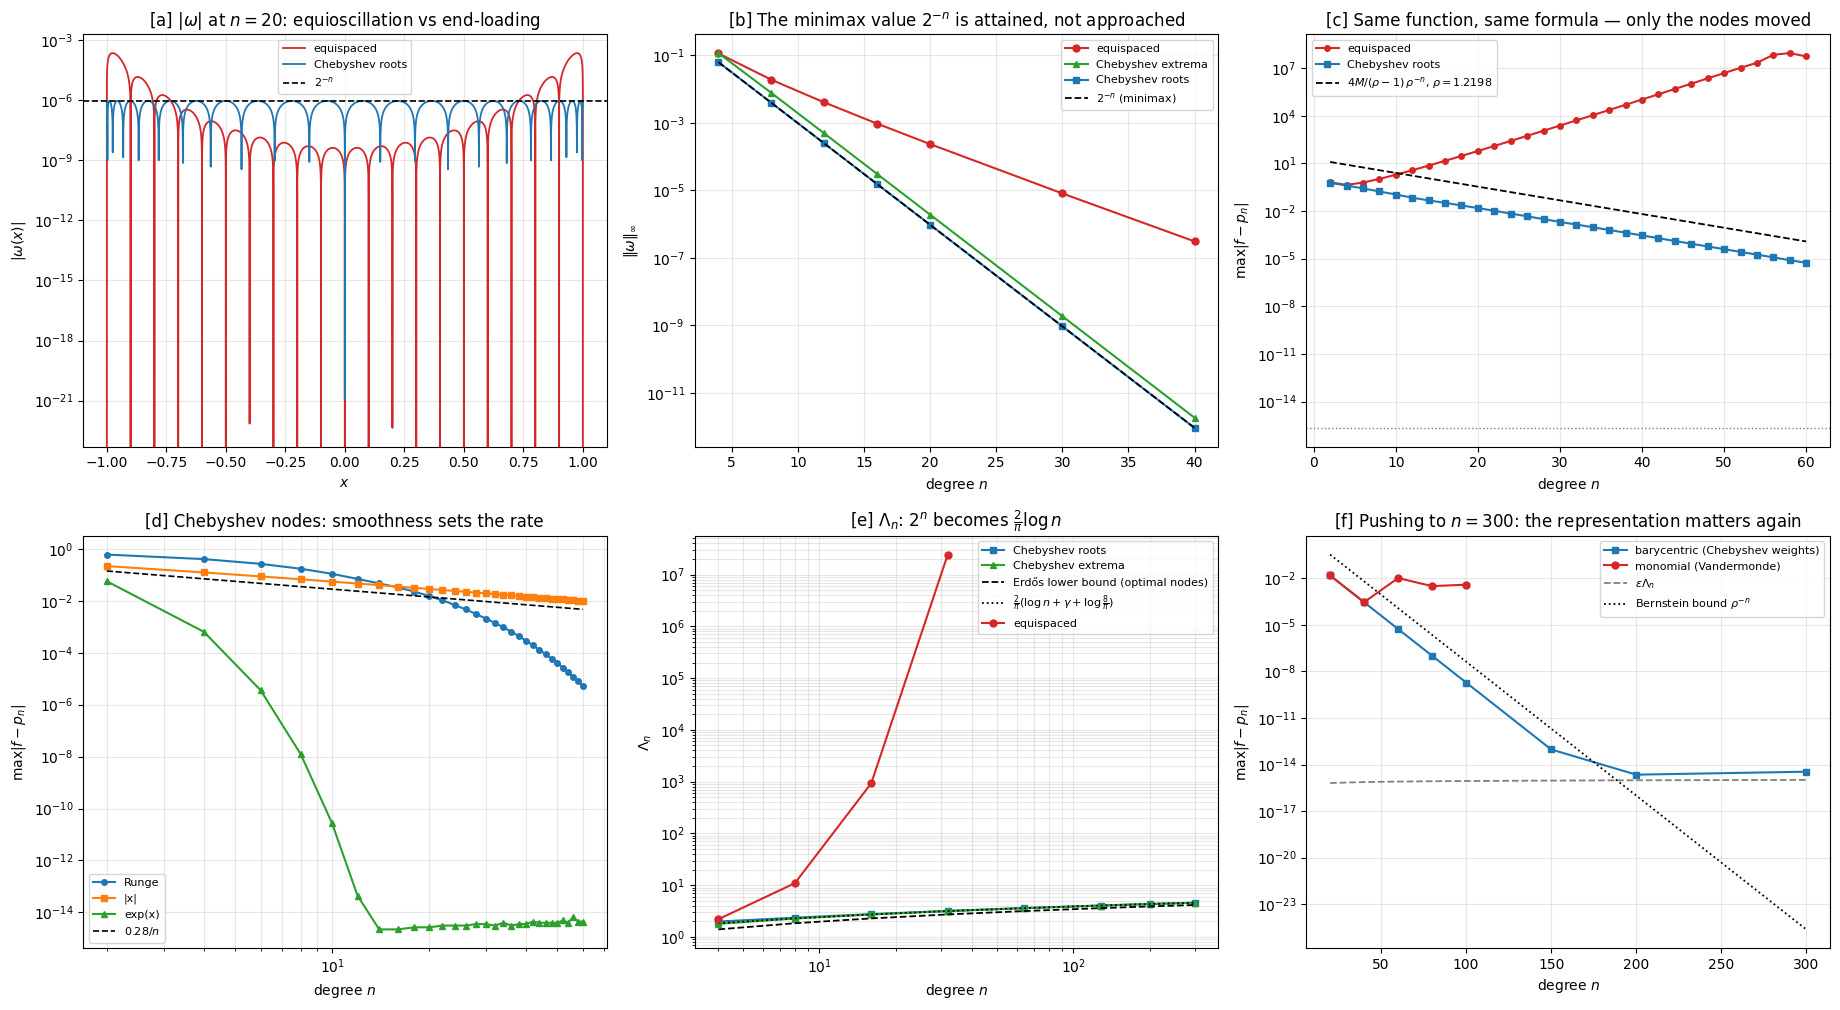

요약
  · 최소최대 : ||omega||_inf = 2^-n 을 Chebyshev 근이 정확히 달성 (n=40 상대차 4.6e-14); 등간격 대비 3.35e+05 배 이득
  · 수렴률   : 측정 rho = 1.218007  vs  Bernstein 1.219804  (상대차 0.147 %, R^2 = 0.99992)
  · Lebesgue : A = 0.62485 (roots) / 0.63745 (extrema)  vs  2/pi = 0.63662
  · 고차     : n=300 무게중심 3.44e-15, 단항식은 n=100 에서 이미 3.92e-03


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [6]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 3, figsize=(18.5, 10.2))

# [a] |omega| 비교
A = ax[0, 0]; n = 20; xw = np.linspace(-1, 1, 20001)
A.semilogy(xw, np.exp(log_abs_omega(nodes_equi(n), xw)), color="tab:red", lw=1.3,
           label="equispaced")
A.semilogy(xw, np.exp(log_abs_omega(nodes_cheb1(n), xw)), color="tab:blue", lw=1.3,
           label="Chebyshev roots")
A.axhline(2.0**(-n), color="k", ls="--", lw=1.2, label=r"$2^{-n}$")
A.set_xlabel("$x$"); A.set_ylabel(r"$|\omega(x)|$")
A.set_title(fr"[a] $|\omega|$ at $n={n}$: equioscillation vs end-loading")
A.legend(fontsize=8); A.grid(alpha=.3)

# [b] ||omega||_inf vs n
B = ax[0, 1]
B.semilogy(O.n, O.equispaced, "o-", ms=5, color="tab:red", label="equispaced")
B.semilogy(O.n, O.cheb_extrema, "^-", ms=5, color="tab:green", label="Chebyshev extrema")
B.semilogy(O.n, O.cheb_roots, "s-", ms=5, color="tab:blue", label="Chebyshev roots")
B.semilogy(O.n, O.theory_2pow, "k--", lw=1.3, label=r"$2^{-n}$ (minimax)")
B.set_xlabel("degree $n$"); B.set_ylabel(r"$\|\omega\|_\infty$")
B.set_title(r"[b] The minimax value $2^{-n}$ is attained, not approached")
B.legend(fontsize=8); B.grid(alpha=.3)

# [c] Runge 수렴 : equi vs cheb
Cx = ax[0, 2]
Cx.semilogy(ns, R["Runge/equi"], "o-", ms=4, color="tab:red", label="equispaced")
Cx.semilogy(ns, R["Runge/cheb"], "s-", ms=4, color="tab:blue", label="Chebyshev roots")
nn = np.array(ns)
Cx.semilogy(nn, 4.0/(rho-1)*rho**(-nn.astype(float)), "k--", lw=1.3,
            label=fr"$4M/(\rho-1)\,\rho^{{-n}}$, $\rho={rho:.4f}$")
Cx.axhline(eps, color="gray", ls=":", lw=1)
Cx.set_xlabel("degree $n$"); Cx.set_ylabel(r"$\max|f-p_n|$")
Cx.set_title("[c] Same function, same formula — only the nodes moved")
Cx.legend(fontsize=8); Cx.grid(alpha=.3)

# [d] 세 함수 (Chebyshev)
D = ax[1, 0]
for name, mk, col in (("Runge","o","tab:blue"), ("|x|","s","tab:orange"), ("exp(x)","^","tab:green")):
    D.loglog(ns, np.maximum(R[f"{name}/cheb"], 1e-18), marker=mk, ms=4, color=col, label=name)
D.loglog(nn, 0.28/nn, "k--", lw=1.2, label=r"$0.28/n$")
D.set_xlabel("degree $n$"); D.set_ylabel(r"$\max|f-p_n|$")
D.set_title("[d] Chebyshev nodes: smoothness sets the rate")
D.legend(fontsize=8); D.grid(alpha=.3, which="both")

# [e] Lebesgue 상수
E = ax[1, 1]
E.semilogy(LB.n, LB.cheb_roots, "s-", ms=5, color="tab:blue", label=r"Chebyshev roots")
E.semilogy(LB.n, LB.cheb_extrema, "^-", ms=5, color="tab:green", label="Chebyshev extrema")
E.semilogy(LB.n, LB.optimal_lower, "k--", lw=1.3, label=r"Erdős lower bound (optimal nodes)")
E.semilogy(LB.n, LB.cheb_asymptotic, "k:", lw=1.3, label=r"$\frac{2}{\pi}(\log n+\gamma+\log\frac{8}{\pi})$")
m_ = LB.equispaced.notna()
E.semilogy(LB.n[m_], LB.equispaced[m_], "o-", ms=5, color="tab:red", label="equispaced")
E.set_xscale("log")
E.set_xlabel("degree $n$"); E.set_ylabel(r"$\Lambda_n$")
E.set_title(r"[e] $\Lambda_n$: $2^n$ becomes $\frac{2}{\pi}\log n$")
E.legend(fontsize=8); E.grid(alpha=.3, which="both")

# [f] 고차 안정성
F = ax[1, 2]
F.semilogy(H.n, H.bary_err, "s-", ms=5, color="tab:blue", label="barycentric (Chebyshev weights)")
mm = H.monomial_err.notna()
F.semilogy(H.n[mm], H.monomial_err[mm], "o-", ms=5, color="tab:red", label="monomial (Vandermonde)")
F.semilogy(H.n, H.eps_Lambda, "--", color="gray", lw=1.3, label=r"$\varepsilon\Lambda_n$")
F.semilogy(H.n, H.bernstein, "k:", lw=1.3, label=r"Bernstein bound $\rho^{-n}$")
F.set_xlabel("degree $n$"); F.set_ylabel(r"$\max|f-p_n|$")
F.set_title("[f] Pushing to $n=300$: the representation matters again")
F.legend(fontsize=8); F.grid(alpha=.3)

plt.tight_layout(); plt.show()

print("요약")
print(f"  · 최소최대 : ||omega||_inf = 2^-n 을 Chebyshev 근이 정확히 달성"
      f" (n=40 상대차 {O[O.n==40].rel_err.iloc[0]:.1e}); 등간격 대비"
      f" {O[O.n==40].equi_over_cheb.iloc[0]:.2e} 배 이득")
print(f"  · 수렴률   : 측정 rho = {math.exp(-sl):.6f}  vs  Bernstein {rho:.6f}"
      f"  (상대차 {abs(math.exp(-sl)-rho)/rho*100:.3f} %, R^2 = {r2:.5f})")
print(f"  · Lebesgue : A = {A1:.5f} (roots) / {A2:.5f} (extrema)  vs  2/pi = {2/math.pi:.5f}")
print(f"  · 고차     : n=300 무게중심 {H[H.n==300].bary_err.iloc[0]:.2e},"
      f" 단항식은 n=100 에서 이미 {H[H.n==100].monomial_err.iloc[0]:.2e}")


## 4. 결과 해석

1. **[2]·[b] — 최소최대는 "근사적으로 좋다" 가 아니라 *정확히 최적*이다.** Chebyshev 근 절점의
   $\|\omega\|_\infty$ 는 $2^{-n}$ 과 상대오차 $10^{-15}$ 수준으로 일치하고, $\omega$ 가
   $2^{-n}T_{n+1}$ 과 같으며, $|\omega|$ 가 $n+2$ 개 점에서 **부호를 번갈아** 최대값을 취한다 —
   최소최대 정리의 증명에 쓰인 등진동 조건이 그대로 관측된다. 무작위 절점 $2\times10^5$ 세트 중
   $2^{-n}$ 을 밑도는 것은 하나도 없고, Nelder–Mead 로 직접 최소화하면 **무작위 시작점에서
   출발해도 Chebyshev 근으로 수렴**한다. 정리를 믿는 것과 재현하는 것은 다른 일이고, 여기서는
   재현했다.

2. **극점 절점은 최적이 아니다 — 정확히 2 배다.** Chebyshev–Lobatto 절점의
   $\|\omega\|_\infty$ 는 $2^{-n}$ 이 아니라 $2^{-n+1}$ 이다. 그럼에도 실무에서 자주 쓰이는
   이유는 $\|\omega\|$ 가 아니라 **$\Lambda_n$ 이 약간 더 작고 끝점을 포함**하기 때문이다
   ([4] 참조). *어떤 기준으로 최적인지*를 명시하지 않으면 "최적 절점" 이라는 말은 뜻이 없다.

3. **[3]·[c] 가 오늘 시리즈의 결론이다.** 같은 함수, 같은 무게중심 공식, **절점만 바꿨는데**
   Problem 2 에서 $n=40$ 에 $1.05\times10^{5}$ 였던 오차가 $2.9\times10^{-4}$ 로 내려간다 —
   같은 $n$ 에서 **$3.6\times10^{8}$ 배**의 이득이고, $n=60$ 에서는 $10^{13}$ 배다.
   더 중요한 것은 *수렴의 종류*다: 등간격에서는 위치마다 다른 수렴/발산이었지만, Chebyshev
   에서는 $[-1,1]$ 전체에서 **균일하게** $\rho^{-n}$ 이다. 측정한 기울기로부터 역산한
   $\rho$ 는 $1.218007$ 로 Bernstein 타원 예측 $1.2198039$ 와 **상대차 $0.147\,\%$**, 적합
   $R^2=0.99992$ 다. **복소평면의 극점 위치 하나가 실축 위 수렴 속도를 소수점까지 정한다.**

4. **[d] — 절점을 고쳤다고 모든 함수가 빨라지지는 않는다.** $|x|$ 는 Chebyshev 절점에서도
   $O(1/n)$ 이고, 측정한 $\log$–$\log$ 기울기가 $-1$ 에 붙는다. $n\cdot\text{err}$ 이
   $0.583\to0.587$ 로 안정되는 것도 확인된다 — 최선근사의 Bernstein 상수 $0.2801$ 의 약 $2.1$ 배로,
   Lebesgue 부등식 $(1+\Lambda_n)E_n$ 이 주는 상계 안에 들어온다. 교훈: **절점 배치는 Runge
   현상(잘못된 절점) 을 고치지만 매끄러움의 부족(함수의 성질) 은 고치지 못한다.** 후자를 고치려면
   다항식을 버리고 조각별 근사로 가야 하고, 그것이 §6 스플라인이다 (Day 109–110).

5. **[e] — $\Lambda_n$ 이 $2^n$ 에서 $\tfrac2\pi\log n$ 으로 내려앉고, *최적과의 거리까지*
   측정된다.** 적합한 계수 $A$ 는 극점 절점에서 $0.63745$ 로 $2/\pi=0.63662$ 와 $0.13\,\%$ 차이고,
   상수항 $B=0.9582$ 도 이론값 $\tfrac2\pi(\gamma+\log\tfrac8\pi)=0.96252$ 에 붙는다.
   더 나아가 **Erdős 하한과의 간격**을 재면 $n$ 이 커질수록
   $0.3950\to0.4412$ 로 수렴하고, $n=300$ 에서 $0.441232$ — 이론값
   $\tfrac2\pi\log 2=0.441271$ 과 $4\times10^{-5}$ 차이다. **Chebyshev 절점은 최적이 아니라
   최적보다 정확히 상수 $\tfrac2\pi\log2$ 만큼 나쁘고, 그 상수는 $n$ 에 무관하다.**
   ("Chebyshev 가 최적" 이라는 흔한 요약은 *차수*에 대해서만 맞는 말이다.)
   실용적 함의가 셋이다. (i) 자료 잡음
   $\delta$ 는 $\log n$ 배로만 증폭된다 — 측정값 보간에도 쓸 수 있다. (ii) Lebesgue 부등식
   $\|f-p_n\|\le(1+\Lambda_n)E_n(f)$ 에서 보간이 **최선근사의 $\log n$ 배 안**에 들어온다.
   (iii) $\varepsilon\Lambda_n$ 이 $n=300$ 에서도 $10^{-15}$ 규모라 반올림이 사실상 증폭되지
   않는다.

6. **[f] — 그러나 표현(representation) 은 다시 문제가 된다.** Chebyshev 절점을 쓰더라도,
   보간다항식을 **단항식 계수로 적으면** $\kappa_2(V)$ 때문에 무너진다. 두 형식의 오차비는
   $n=40$ 까지 $1.01$ 로 구별이 안 되다가 $n=60$ 에서 $1.9\times10^{3}$, $n=100$ 에서
   $2.0\times10^{6}$ 으로 갈라진다 — 정확히 $\kappa_2(V)$ 가 $10^{15}$ 에서 $10^{18}$ 로 넘어가는
   구간이다.
   무게중심 형식은 $n=300$ 까지 기계정밀도 근처에서 평평하게 간다. Problem 1 에서 "$\kappa_2(V)$ 가
   $10^{15}$ 여도 값은 멀쩡하더라" 고 했던 것은 $n\le 40$ 에서의 이야기였고, **$n$ 을 충분히
   밀면 결국 계수의 조건수가 값을 잡아먹는다.** 두 조건수는 다른 양이지만 무한히 독립인 것은
   아니다.

7. **오차 곡선의 세 구간을 하나의 그림에서 읽을 수 있다** ([f]). Bernstein 상계가 $\varepsilon$
   아래로 내려가는 $n\approx 200$ 까지가 **절단오차 구간**, 그 위는 $\varepsilon\Lambda_n$ 이
   지배하는 **반올림 구간** (측정 $3.4\times10^{-15}$ 대 $\varepsilon\Lambda_{300}=1.0\times10^{-15}$),
   그리고 단항식 곡선은 어느 쪽도 아닌 **표현의 붕괴**다. Day 102 가 Ch 15 를 닫으며 정리한
   세 질문 — *문제가 얼마나 나쁜 조건인가 · 알고리즘이 안정한가 · 오차가 일에 대해 얼마나 빨리
   주는가* — 이 한 그림에 그대로 들어 있다.

> **결론**: 절점은 자유변수이고, 그것을 $\|\omega\|_\infty$ 최소화로 고르면 답은 유일하게
> **Chebyshev 근**이며 최소값은 $2^{-n}$ 이다. 그 한 번의 교체가 발산을 $\rho^{-n}$ 균일수렴으로,
> $\Lambda_n\sim 2^n$ 을 $\tfrac2\pi\log n$ 으로 바꾼다. **고쳐야 할 것은 알고리즘이 아니라
> 입력의 배치였다.**

**다음 단원으로의 연결** — Day 104 (§4.2) 는 오늘 계속 빌려 쓴 오차 정리
$f(x)-p_n(x)=f^{(n+1)}(\xi_x)\,\omega(x)/(n+1)!$ 를 **증명하고**, $\xi_x$ 의 존재를 Rolle 정리로
세운 뒤 절점 선택 문제를 정면으로 다룬다. 오늘 실험적으로 얻은 $2^{-n}$ 과 $\rho^{-n}$ 이
거기서 정리의 따름정리로 다시 나온다.